In [2]:
%load_ext IPython.extensions.autoreload

import sys
import os
# Add the parent directory (TRAIN-TICKET-PRICING) to the system path
sys.path.append(os.path.abspath(".."))
from preprocessing.features import clean_base_data, engineer_time_features, engineer_customer_strength_features, engineer_scarcity_features, drop_features

The IPython.extensions.autoreload extension is already loaded. To reload it, use:
  %reload_ext IPython.extensions.autoreload


In [ ]:
import pandas as pd
import numpy as np
import mlflow
import mlflow.sklearn
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, TargetEncoder, FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.feature_selection import SelectKBest, mutual_info_regression
from sklearn.model_selection import RandomizedSearchCV

pd.set_option("display.max_columns", None)
import warnings
warnings.filterwarnings('ignore')

In [4]:
df = pd.read_csv(r'../Dataset/processed_travel_data.csv')
df.head()

,booking_id,customer_id,route_id,ticket_price_gbp,seat_class,booking_channel,origin,destination,distance_km,route_category,customer_segment,loyalty_status,remaining_seats_realized,days_before_travel,booking_month,travel_month,is_weekend_travel,customer_quarterly_revenue,scarcity_index
0,B000000087,C000971,R0001,51.81,Standard,Web,Aberdeen,Leeds,264,Medium,Leisure,Not loyal,116,58,11,1,0,35.22,0.470905
1,B000000012,C004636,R0001,53.74,Standard,Web,Aberdeen,Leeds,264,Medium,Leisure,Gold,116,51,11,1,0,83.32,0.470905
2,B000000021,C004403,R0001,69.01,Flex,Web,Aberdeen,Leeds,264,Medium,Leisure,Not loyal,116,46,11,1,0,78.14,0.470905
3,B000000064,C010229,R0001,98.86,First,Mobile,Aberdeen,Leeds,264,Medium,Leisure,Not loyal,116,43,11,1,0,181.16,0.470905
4,B000000077,C009319,R0001,56.89,Standard,Mobile,Aberdeen,Leeds,264,Medium,Leisure,Not loyal,116,43,11,1,0,201.96,0.470905


In [5]:
df.columns

Index(['booking_id', 'customer_id', 'route_id', 'ticket_price_gbp',
       'seat_class', 'booking_channel', 'origin', 'destination', 'distance_km',
       'route_category', 'customer_segment', 'loyalty_status',
       'remaining_seats_realized', 'days_before_travel', 'booking_month',
       'travel_month', 'is_weekend_travel', 'customer_quarterly_revenue',
       'scarcity_index'],
      dtype='object')

In [6]:
df['seat_class'].value_counts()

seat_class
Standard    374168
Flex        114228
First        31317
Name: count, dtype: int64

In [8]:
df.groupby("seat_class")["ticket_price_gbp"].mean()

seat_class
First       95.971350
Flex        66.892387
Standard    54.814970
Name: ticket_price_gbp, dtype: float64

In [9]:
df.groupby("route_category")["ticket_price_gbp"].mean()

route_category
Long      95.962253
Medium    61.325856
Short     28.420587
Name: ticket_price_gbp, dtype: float64

#### seat_class and route_category are ordinal columns

- Standard < Flex < First for seat_class
- Short < Medium < Long for route_category

In [10]:
cat_features = df.select_dtypes(include=['object']).columns.to_list()[2:]
num_features = df.select_dtypes(include=['float', 'int']).columns.to_list()[1:]

features = cat_features + num_features

In [12]:
X = df[features]
y = df['ticket_price_gbp']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Training and Selecting a Base Model

In [9]:
preprocessor = ColumnTransformer(
    transformers=[
        ('ohe_enc', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features),
        ('num_scale', StandardScaler(), num_features)
    ]
)

In [11]:
# base model selection

from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

models = {
    'Linear_Regression': LinearRegression(),
    'Random_Forest': RandomForestRegressor(random_state=42),
    'Gradient_Boosting': GradientBoostingRegressor(random_state=42)
}

for name, model in models.items():
    pipeline = Pipeline(
    [
        ('cleaning', FunctionTransformer(clean_base_data)),
        ('engineer_time_features', FunctionTransformer(engineer_time_features)),
        ('engineer_customer_strength_features', FunctionTransformer(engineer_customer_strength_features)),
        ('engineer_scarcity_features', FunctionTransformer(engineer_scarcity_features)),
        ('drop_features', FunctionTransformer(drop_features)),
        ('preprocess', preprocessor),
        ('regressor', model)
    ]
    )

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    print(f'>>> Evaluation for {name} <<<')
    print(f'MAE: {mean_absolute_error(y_test, y_pred)}')
    print(f'r2_score: {r2_score(y_test, y_pred)}')
    print(f'MSE: {mean_squared_error(y_test, y_pred)}')
    print(f'RMSE: {np.sqrt(mean_squared_error(y_test, y_pred))}\n')

>>> Evaluation for Linear_Regression <<<
MAE: 11.193173409382124
r2_score: 0.7132227675427378
MSE: 263.3035790326453
RMSE: 16.226631783356808

>>> Evaluation for Random_Forest <<<
MAE: 3.1158328834324487
r2_score: 0.9637629607066716
MSE: 33.27091923485208
RMSE: 5.768094939826501

>>> Evaluation for Gradient_Boosting <<<
MAE: 9.034961628048087
r2_score: 0.8069378344757054
MSE: 177.25939651054918
RMSE: 13.313879844378542



## Optimizing Random Forest (Best Base) Model

In [13]:
from sklearn.preprocessing import OrdinalEncoder

ordinal_cols = ['route_category', 'seat_class']
nominal_cols = [col for col in cat_features if col not in ordinal_cols]

ordinal_categories = [
    ['Short', 'Medium', 'Long'],  # route_category
    ['Standard', 'Flex', 'First']  # seat_class
]

rf_preprocessor = ColumnTransformer(
    transformers=[
        ('ord', OrdinalEncoder(categories=ordinal_categories), ordinal_cols),
        ('nom', OneHotEncoder(handle_unknown='ignore', sparse_output=False), nominal_cols)
    ],
    remainder='passthrough'
)

# ensuring ColumnTransformer's output is a dataframe with column names instead of index numbers
rf_preprocessor.set_output(transform="pandas")

X_train_prepped = rf_preprocessor.fit_transform(X_train)

In [14]:
# Using a 100,000 row sample for feature selection
sample_size = min(100000, X_train_prepped.shape[0])

# feature selection
n = 35
selector = SelectKBest(score_func=mutual_info_regression, k=n)
selector.fit(X_train_prepped.iloc[:sample_size], y_train.iloc[:sample_size])

# Get the exact names of the top n columns
top_n_names = X_train_prepped.columns[selector.get_support()].tolist()

In [15]:
# Optimizing Random Forest model using RandomizedSearchCV
rf_model = RandomForestRegressor(random_state=42, n_jobs=-1)

param_dist = {
    'n_estimators': [100, 300, 500],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt'],
    'max_samples': [0.5] 
}

rf_search = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=param_dist,
    n_iter=10, 
    cv=3,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

# Train using only the pre-selected top n columns
rf_search.fit(X_train_prepped[top_n_names], y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


RandomizedSearchCV(cv=3,
                   estimator=RandomForestRegressor(n_jobs=-1, random_state=42),
                   n_jobs=-1,
                   param_distributions={'max_depth': [10, 20, None],
                                        'max_features': ['sqrt'],
                                        'max_samples': [0.5],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 300, 500]},
                   random_state=42, scoring='neg_mean_absolute_error',
                   verbose=1)

In [16]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

def select_features(X):
    return X[top_n_names]

optimized_pipeline = Pipeline([
    ('cleaning', FunctionTransformer(clean_base_data)),
    ('engineer_time_features', FunctionTransformer(engineer_time_features)),
    ('engineer_customer_strength_features', FunctionTransformer(engineer_customer_strength_features)),
    ('engineer_scarcity_features', FunctionTransformer(engineer_scarcity_features)),
    ('drop_features', FunctionTransformer(drop_features)),
    ('preprocessor', rf_preprocessor),
    ('selector', FunctionTransformer(select_features)),
    ('model', rf_search.best_estimator_)
])

# Generate predictions for the test set
y_pred = optimized_pipeline.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

### Model Explanability Using SHAP

In [17]:
import shap
import matplotlib.pyplot as plt

# Transforming the test data into the final top n numeric features
# using a sample test data of 200 rows
X_test_transformed = optimized_pipeline[:-1].transform(X_test[:200])

# get the trained model from the pipeline
model = optimized_pipeline.named_steps['model']

# Initialize the SHAP Explainer
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_transformed)

# Store the base value (the average prediction) for waterfall plot
expected_value = explainer.expected_value

In [18]:
expected_value

array([59.94394877])

In [19]:
base_val = float(expected_value[0])

### Logging Model Parameters, Metrics, Pipeline and SHAP Plots to MLFlow

2026/03/06 18:17:20 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/06 18:17:21 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



RMSE: 6.4350, MAE: 3.6316, R2: 0.9549



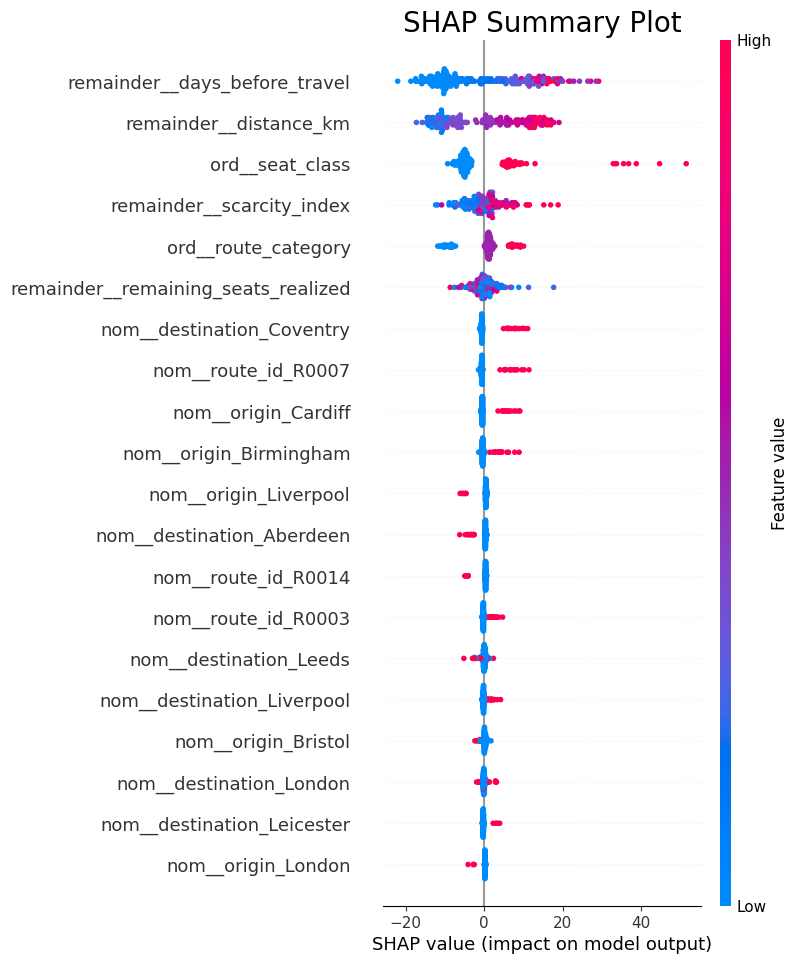

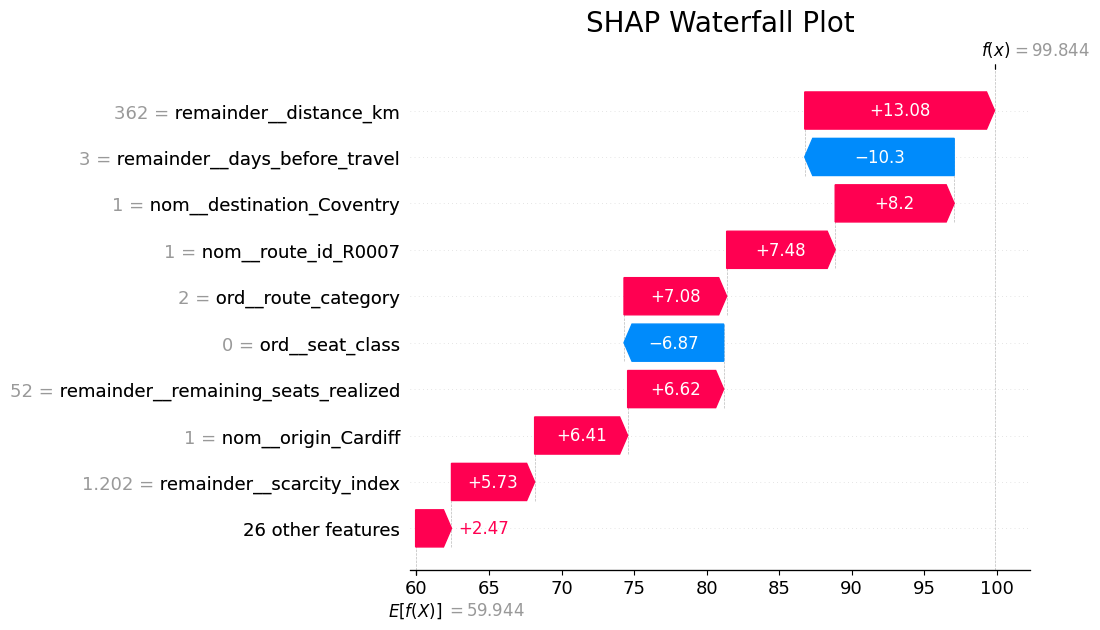

🏃 View run optimized_model at: http://127.0.0.1:5000/#/experiments/1/runs/2cdb4d233c424d00a974eb1c5f212a2d
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


In [21]:
# setting mlflow experiment
mlflow.set_tracking_uri('http://127.0.0.1:5000')
mlflow.set_experiment('Voyage_ticket_price_prediction')

# Logging with mlflow
with mlflow.start_run(run_name="optimized_model"):
    # Log selected features, model type and best hyperparameters
    mlflow.log_param("selected_features", top_n_names)
    mlflow.log_param("model_type", optimized_pipeline.named_steps['model'].__class__.__name__)
    mlflow.log_params(rf_search.best_params_)

    # Log Metrics
    mlflow.log_metric("mae", mae)
    mlflow.log_metric("mse", mse)
    mlflow.log_metric("rmse", rmse)
    mlflow.log_metric("r2_score", r2)
    
    # Log the Full Pipeline
    mlflow.sklearn.log_model(optimized_pipeline, "pipeline")

    print(f"\nRMSE: {rmse:.4f}, MAE: {mae:.4f}, R2: {r2:.4f}\n")

    # Log SHAP Summary Plot
    plt.figure(figsize=(6, 4))
    shap.summary_plot(shap_values, X_test_transformed, show=False)
    mlflow.log_figure(plt.gcf(), "plots/shap_summary.png")
    plt.title('SHAP Summary Plot', fontsize=20)
    plt.show() 
    plt.close()
    
    # Log SHAP waterfall plot for row index 0
    exp = shap.Explanation(
        values = shap_values[0], 
        base_values = base_val, 
        data = X_test_transformed.iloc[0].values,
        feature_names = X_test_transformed.columns.tolist()
    )
    plt.figure(figsize=(5, 3))
    shap.plots.waterfall(exp, show=False)
    mlflow.log_figure(plt.gcf(), "plots/shap_waterfall_row0.png")
    plt.title('SHAP Waterfall Plot', fontsize=20)
    plt.show()
    plt.close()